# 02 - Amdahl analysis

Input:

- `analysis_output/preprocessed_core_data.csv`

Outputs:

- `analysis_output/amdahl_analysis.csv`
- `analysis_output/amdahl_fit.png`

Amdahl's Law model:

\[
S_p = \frac{1}{f + \frac{1-f}{p}}
\]

where:

- \(S_p\) is speedup
- \(p\) is process count
- \(f\) is the estimated serial fraction

This notebook fits \(f\) from the observed speedup curve.


In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import curve_fit
except Exception:
    curve_fit = None
    
SOURCE = "newest"
OUTPUT_DIR = Path("analysis_output")
INPUT_CSV = OUTPUT_DIR / f"preprocessed_data_{SOURCE}.csv"

df = pd.read_csv(INPUT_CSV)


In [13]:
agg = (
    df.groupby(["workers", "cores"], as_index=False)
    .agg(
        runs=("time_s", "size"),
        time_mean_s=("time_s", "mean"),
        bab_nodes_mean=("bab_nodes", "mean"),
    )
    .sort_values("cores")
    .reset_index(drop=True)
)

baseline = agg.iloc[0]
baseline_cores = baseline["cores"]
baseline_time = baseline["time_mean_s"]

agg["speedup"] = baseline_time / agg["time_mean_s"]
agg["relative_cores"] = agg["cores"] / baseline_cores

display(agg)


,workers,cores,runs,time_mean_s,bab_nodes_mean,speedup,relative_cores
0,7,8,1,1234.405245,17757.0,1.000000,1.0
1,15,16,1,592.235753,17811.0,2.084314,2.0
2,63,64,1,147.406386,17761.0,8.374164,8.0
3,127,128,1,75.849920,17729.0,16.274312,16.0
4,255,256,1,46.394310,17813.0,26.606824,32.0
5,511,512,1,28.819229,17735.0,42.832695,64.0
6,1023,1024,1,16.589059,17829.0,74.410806,128.0


In [14]:
def amdahl_speedup(p, f):
    return 1.0 / (f + (1.0 - f) / p)

if curve_fit is None:
    print("scipy is not installed. Skipping fit.")
    estimated_f = np.nan
    max_speedup = np.nan
else:
    x = agg["relative_cores"].astype(float).to_numpy()
    y = agg["speedup"].astype(float).to_numpy()

    if len(x) < 3:
        print("Need at least 3 process counts for a useful Amdahl fit.")
        estimated_f = np.nan
        max_speedup = np.nan
    else:
        popt, _ = curve_fit(
            amdahl_speedup,
            x,
            y,
            p0=[0.05],
            bounds=([0.0], [1.0]),
            maxfev=10000,
        )
        estimated_f = float(popt[0])
        max_speedup = np.inf if estimated_f == 0 else 1.0 / estimated_f

print(f"Estimated serial fraction f: {estimated_f}")
print(f"Theoretical maximum speedup 1/f: {max_speedup}")


Estimated serial fraction f: 0.0059480046692961756
Theoretical maximum speedup 1/f: 168.12360709164162


In [15]:
out_df = agg.copy()
out_df["amdahl_estimated_serial_fraction_f"] = estimated_f
out_df["amdahl_max_speedup_1_over_f"] = max_speedup

out = OUTPUT_DIR / f"amdahl_analysis_{SOURCE}.csv"
out_df.to_csv(out, index=False)
display(out_df)
print(f"Saved: {out}")


,workers,cores,runs,time_mean_s,bab_nodes_mean,speedup,relative_cores,amdahl_estimated_serial_fraction_f,amdahl_max_speedup_1_over_f
0,7,8,1,1234.405245,17757.0,1.000000,1.0,0.005948,168.123607
1,15,16,1,592.235753,17811.0,2.084314,2.0,0.005948,168.123607
2,63,64,1,147.406386,17761.0,8.374164,8.0,0.005948,168.123607
3,127,128,1,75.849920,17729.0,16.274312,16.0,0.005948,168.123607
4,255,256,1,46.394310,17813.0,26.606824,32.0,0.005948,168.123607
5,511,512,1,28.819229,17735.0,42.832695,64.0,0.005948,168.123607
6,1023,1024,1,16.589059,17829.0,74.410806,128.0,0.005948,168.123607


Saved: analysis_output/amdahl_analysis_newest.csv


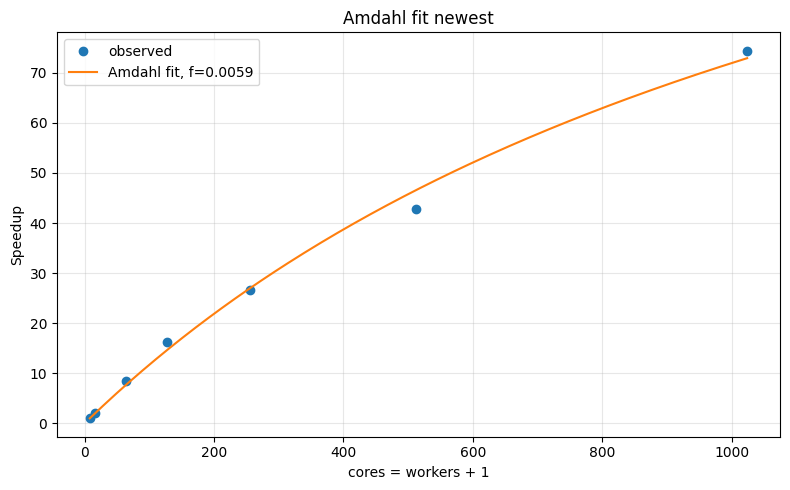

Saved: analysis_output/amdahl_fit_newest.png


In [16]:
plt.figure(figsize=(8, 5))

plt.plot(agg["cores"], agg["speedup"], marker="o", linestyle="", label="observed")

if np.isfinite(estimated_f):
    x_proc = np.linspace(agg["cores"].min(), agg["cores"].max(), 200)
    x_rel = x_proc / baseline_cores
    y_fit = amdahl_speedup(x_rel, estimated_f)
    plt.plot(x_proc, y_fit, label=f"Amdahl fit, f={estimated_f:.4f}")

plt.xlabel("cores = workers + 1")
plt.ylabel("Speedup")
plt.title(f"Amdahl fit {SOURCE}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out = OUTPUT_DIR / f"amdahl_fit_{SOURCE}.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")
